# QUT-DV25 — Algorithm Performance Summary

This notebook collects **Accuracy, Precision, Recall, and F1 Score** for every algorithm across all trace types and analysis categories, then produces comparison tables and charts.

**Sources**
- Traditional ML (TML): `model_comparison_results.csv` files in each trace-type subfolder  
- Transformer Model: test metrics extracted from `Transformer Model.ipynb` output  
- CNN: best validation accuracy extracted from `CNN_Results.csv` (final test Precision/Recall/F1 not stored separately)


In [1]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)


## 1. Load Traditional ML Results

In [2]:
BASE_TML = os.path.join(
    os.path.dirname(os.path.abspath("__file__")),
    "QUT-DV25_Step 2 Traditional ML Implementation"
)

records = []
for root, dirs, files in sorted(os.walk(BASE_TML)):
    for fname in sorted(files):
        if fname == "model_comparison_results.csv":
            fpath = os.path.join(root, fname)
            rel   = os.path.relpath(fpath, BASE_TML)
            parts = rel.replace("\\", "/").split("/")
            # parts[0] = analysis category, parts[1] = trace type (may not exist for flat dirs)
            if len(parts) == 3:
                analysis_type = parts[0]    # e.g. "Dynamic Analysis"
                trace_type    = parts[1]    # e.g. "CombinedTraces"
            else:
                analysis_type = parts[0]
                trace_type    = "—"
            df = pd.read_csv(fpath)
            df["Analysis Type"] = analysis_type
            df["Trace Type"]    = trace_type
            records.append(df)

tml_df = pd.concat(records, ignore_index=True)

# Rename columns for consistency
tml_df.rename(columns={
    "Test Accuracy": "Accuracy",
    "F1 Score":      "F1 Score",
    "Cohen\'s Kappa": "Kappa",
}, inplace=True)
# Keep only key metric columns
keep_cols = ["Analysis Type", "Trace Type", "Model",
             "Accuracy", "Precision", "Recall", "F1 Score",
             "ROC AUC", "Cohen's Kappa"]
tml_df = tml_df[[c for c in keep_cols if c in tml_df.columns]]

print(f"Loaded {len(tml_df)} TML rows from {len(records)} CSV files.")
tml_df.head(10)


Loaded 54 TML rows from 9 CSV files.


,Analysis Type,Trace Type,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Dynamic Analysis,CombinedTraces,Random Forest,0.9600,0.9601,0.9600,0.9600,0.9937
1,Dynamic Analysis,CombinedTraces,Decision Tree,0.9402,0.9436,0.9402,0.9401,0.9851
2,Dynamic Analysis,CombinedTraces,SVM,0.9528,0.9531,0.9528,0.9528,0.9862
3,Dynamic Analysis,CombinedTraces,Logistic Regression,0.9505,0.9505,0.9505,0.9505,0.9893
4,Dynamic Analysis,CombinedTraces,KNN,0.8337,0.8337,0.8337,0.8337,0.9110
5,Dynamic Analysis,CombinedTraces,Gradient Boosting,0.9411,0.9443,0.9411,0.9410,0.9853
6,Dynamic Analysis,FiletopTraces,Random Forest,0.9201,0.9211,0.9201,0.9201,0.9776
7,Dynamic Analysis,FiletopTraces,Decision Tree,0.8688,0.8688,0.8688,0.8688,0.8709
8,Dynamic Analysis,FiletopTraces,SVM,0.8977,0.8986,0.8977,0.8977,0.9630
9,Dynamic Analysis,FiletopTraces,Logistic Regression,0.9052,0.9053,0.9052,0.9052,0.9693


## 2. Load Deep Learning Results

In [3]:
# ── Transformer Model ──────────────────────────────────────────────────────────
# Metrics extracted from 'Transformer Model.ipynb' execution output
transformer_row = {
    "Analysis Type": "Dynamic Analysis",
    "Trace Type":    "CombinedTraces",
    "Model":         "Transformer",
    "Accuracy":      0.93507707,
    "Precision":     0.93495146,
    "Recall":        0.93043478,
    "F1 Score":      0.93268765,
    "ROC AUC":       0.93492806,
    "Cohen's Kappa": 0.86999102,
}

# ── CNN ────────────────────────────────────────────────────────────────────────
# CNN_Results.csv holds per-epoch training/validation history only.
# Best checkpoint = epoch 72, highest Validation Accuracy = 0.9528.
# Final test Precision / Recall / F1 are not stored separately in the repo.
CNN_RESULTS = os.path.join(
    os.path.dirname(os.path.abspath("__file__")),
    "QUT-DV25_Step 3 DL Implementation",
    "CNN", "CNN_Results.csv"
)
cnn_hist = pd.read_csv(CNN_RESULTS)
best_cnn = cnn_hist.loc[cnn_hist["Validation Accuracy"].idxmax()]
print(f"CNN best epoch: {int(best_cnn['Epoch'])} | "
      f"Train Acc: {best_cnn['Train Accuracy']:.4f} | "
      f"Val Acc:   {best_cnn['Validation Accuracy']:.4f}")

cnn_row = {
    "Analysis Type": "Dynamic Analysis",
    "Trace Type":    "CombinedTraces",
    "Model":         "CNN (best val acc)",
    "Accuracy":      best_cnn["Validation Accuracy"],  # best validation accuracy
    "Precision":     float("nan"),
    "Recall":        float("nan"),
    "F1 Score":      float("nan"),
    "ROC AUC":       float("nan"),
    "Cohen's Kappa": float("nan"),
}

dl_df = pd.DataFrame([transformer_row, cnn_row])
print(dl_df)


CNN best epoch: 72 | Train Acc: 0.9997 | Val Acc:   0.9528
      Analysis Type      Trace Type               Model  Accuracy  Precision  \
0  Dynamic Analysis  CombinedTraces         Transformer    0.9351     0.9350   
1  Dynamic Analysis  CombinedTraces  CNN (best val acc)    0.9528        NaN   

   Recall  F1 Score  ROC AUC  Cohen's Kappa  
0  0.9304    0.9327   0.9349         0.8700  
1     NaN       NaN      NaN            NaN  


## 3. Combined Performance Summary Table

In [4]:
summary_df = pd.concat([tml_df, dl_df], ignore_index=True)

# Round metrics
for col in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC", "Cohen's Kappa"]:
    if col in summary_df.columns:
        summary_df[col] = summary_df[col].round(4)

print(f"Total rows: {len(summary_df)}")
summary_df


Total rows: 56


,Analysis Type,Trace Type,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Cohen's Kappa
0,Dynamic Analysis,CombinedTraces,Random Forest,0.9600,0.9601,0.9600,0.9600,0.9937,NaN
1,Dynamic Analysis,CombinedTraces,Decision Tree,0.9402,0.9436,0.9402,0.9401,0.9851,NaN
2,Dynamic Analysis,CombinedTraces,SVM,0.9528,0.9531,0.9528,0.9528,0.9862,NaN
3,Dynamic Analysis,CombinedTraces,Logistic Regression,0.9505,0.9505,0.9505,0.9505,0.9893,NaN
4,Dynamic Analysis,CombinedTraces,KNN,0.8337,0.8337,0.8337,0.8337,0.9110,NaN
5,Dynamic Analysis,CombinedTraces,Gradient Boosting,0.9411,0.9443,0.9411,0.9410,0.9853,NaN
6,Dynamic Analysis,FiletopTraces,Random Forest,0.9201,0.9211,0.9201,0.9201,0.9776,NaN
7,Dynamic Analysis,FiletopTraces,Decision Tree,0.8688,0.8688,0.8688,0.8688,0.8709,NaN
8,Dynamic Analysis,FiletopTraces,SVM,0.8977,0.8986,0.8977,0.8977,0.9630,NaN
9,Dynamic Analysis,FiletopTraces,Logistic Regression,0.9052,0.9053,0.9052,0.9052,0.9693,NaN


In [5]:
out_csv = os.path.join(
    os.path.dirname(os.path.abspath("__file__")), "..", "performance_summary.csv"
)
summary_df.to_csv(out_csv, index=False)
print(f"Saved summary CSV → {os.path.abspath(out_csv)}")


Saved summary CSV → /home/runner/work/QUT-DV25/QUT-DV25/performance_summary.csv


## 4. Heatmap — F1 Score Across All Trace Types and Algorithms

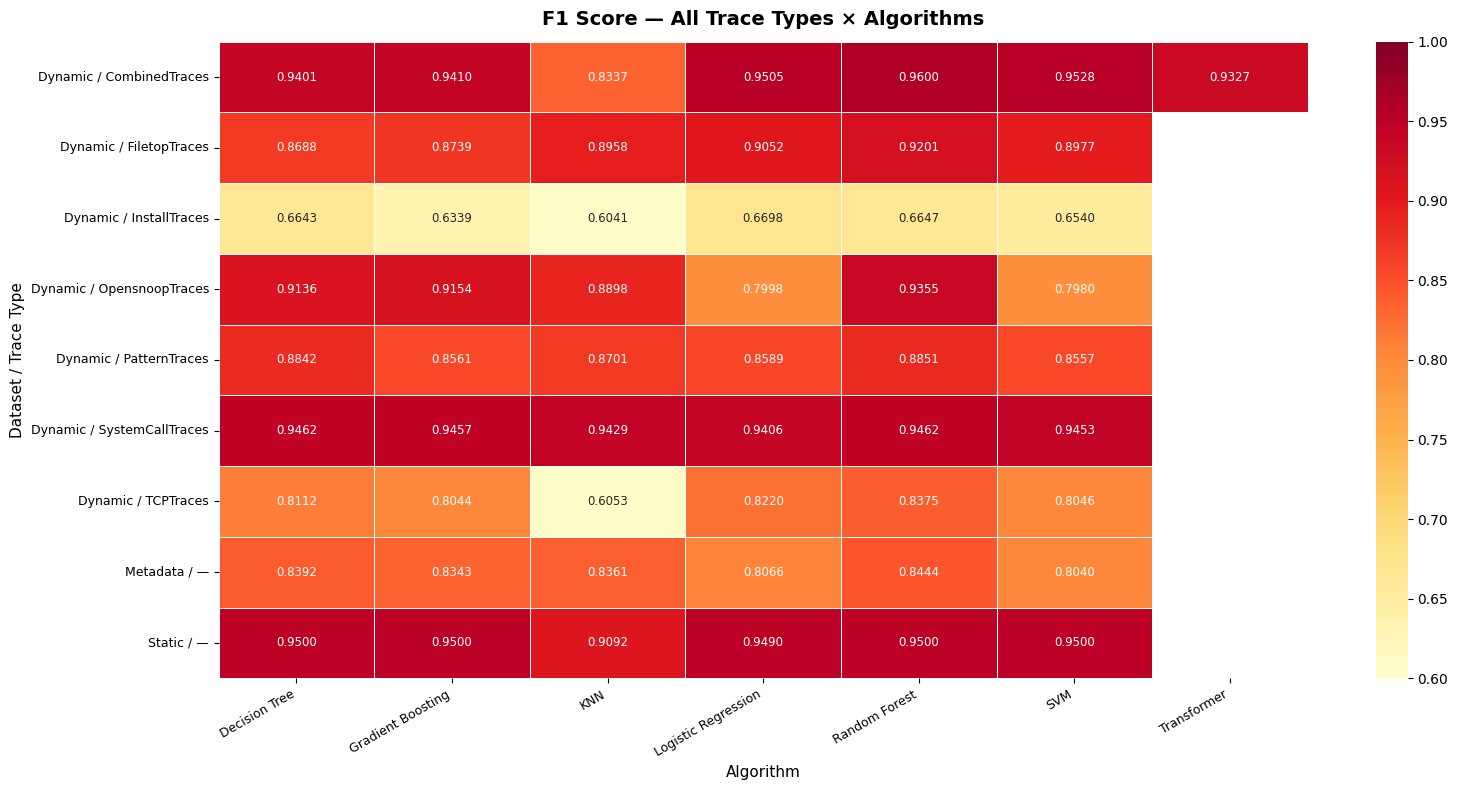

Saved → /home/runner/work/QUT-DV25/QUT-DV25/graph_f1_heatmap.png


In [6]:
# Pivot: rows = Trace Type label, cols = Model, values = F1 Score
heat_df = summary_df.copy()
heat_df["Dataset"] = heat_df["Analysis Type"].str.replace(" Analysis", "") + " / " + heat_df["Trace Type"]
pivot = heat_df.pivot_table(index="Dataset", columns="Model", values="F1 Score")
pivot = pivot.sort_index()

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    pivot, annot=True, fmt=".4f", cmap="YlOrRd",
    linewidths=0.5, annot_kws={"size": 8.5},
    ax=ax, vmin=0.60, vmax=1.00
)
ax.set_title("F1 Score — All Trace Types × Algorithms", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Algorithm", fontsize=11)
ax.set_ylabel("Dataset / Trace Type", fontsize=11)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
out_heatmap = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "graph_f1_heatmap.png")
plt.savefig(out_heatmap, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {os.path.abspath(out_heatmap)}")


## 5. Grouped Bar Charts — Accuracy, Precision, Recall, F1 per Trace Type

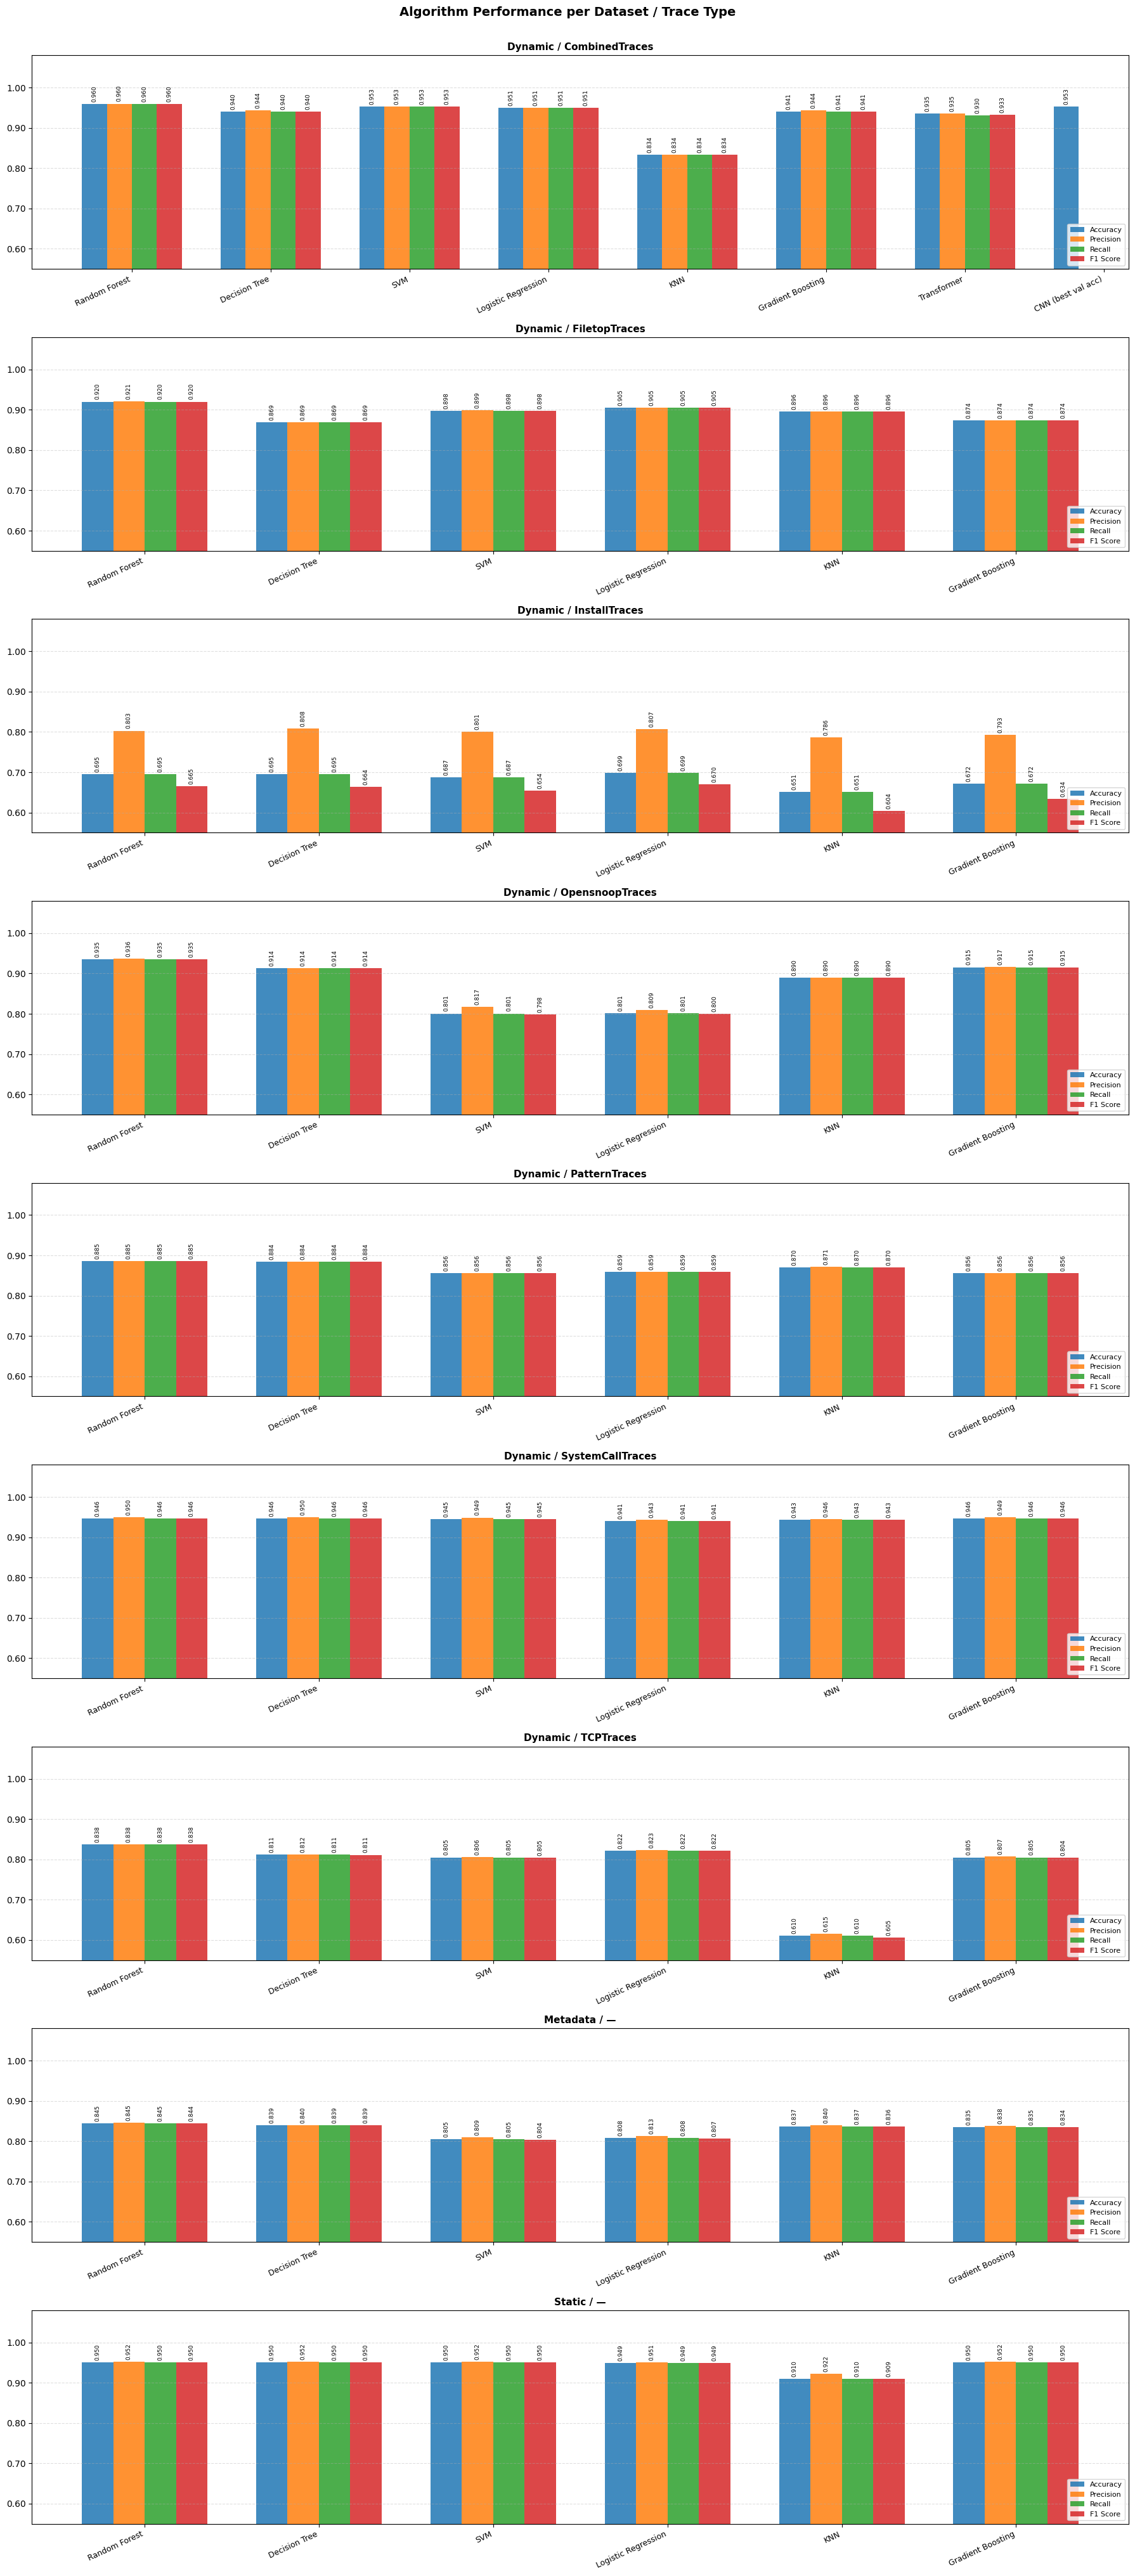

Saved → /home/runner/work/QUT-DV25/QUT-DV25/graph_per_tracetype_metrics.png


In [7]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
ALGORITHMS = [
    "Random Forest", "Decision Tree", "SVM",
    "Logistic Regression", "KNN", "Gradient Boosting",
    "Transformer", "CNN (best val acc)"
]
COLORS = plt.cm.tab10.colors

datasets = summary_df["Dataset"].unique() if "Dataset" in summary_df.columns else (
    (summary_df["Analysis Type"].str.replace(" Analysis", "") + " / " + summary_df["Trace Type"]).unique()
)
heat_df2 = summary_df.copy()
if "Dataset" not in heat_df2.columns:
    heat_df2["Dataset"] = heat_df2["Analysis Type"].str.replace(" Analysis","") + " / " + heat_df2["Trace Type"]

n_datasets = heat_df2["Dataset"].nunique()
fig, axes = plt.subplots(n_datasets, 1, figsize=(18, 4.5 * n_datasets), sharex=False)
if n_datasets == 1:
    axes = [axes]

for ax, (ds_name, grp) in zip(axes, sorted(heat_df2.groupby("Dataset"))):
    models   = grp["Model"].tolist()
    x        = np.arange(len(models))
    width    = 0.18
    offsets  = np.linspace(-0.27, 0.27, len(metrics))
    for idx, metric in enumerate(metrics):
        vals = grp[metric].values.astype(float)
        bars = ax.bar(x + offsets[idx], vals, width, label=metric, color=COLORS[idx], alpha=0.85)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f"{v:.3f}", ha="center", va="bottom", fontsize=6.5, rotation=90)
    ax.set_title(ds_name, fontsize=11, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=25, ha="right", fontsize=9)
    ax.set_ylim(0.55, 1.08)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.suptitle("Algorithm Performance per Dataset / Trace Type", fontsize=14, fontweight="bold", y=1.002)
plt.tight_layout()
out_bar = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "graph_per_tracetype_metrics.png")
plt.savefig(out_bar, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {os.path.abspath(out_bar)}")


## 6. Best Algorithm per Dataset (by F1 Score)

In [8]:
if "Dataset" not in summary_df.columns:
    summary_df["Dataset"] = summary_df["Analysis Type"].str.replace(" Analysis","") + " / " + summary_df["Trace Type"]

best_per_ds = (
    summary_df.dropna(subset=["F1 Score"])
    .sort_values("F1 Score", ascending=False)
    .groupby("Dataset")
    .first()
    .reset_index()[["Dataset", "Model", "Accuracy", "Precision", "Recall", "F1 Score"]]
)
print("Best algorithm per dataset (highest F1):")
print(best_per_ds.to_string(index=False))


Best algorithm per dataset (highest F1):
                   Dataset               Model  Accuracy  Precision  Recall  F1 Score
  Dynamic / CombinedTraces       Random Forest    0.9600     0.9601  0.9600    0.9600
   Dynamic / FiletopTraces       Random Forest    0.9201     0.9211  0.9201    0.9201
   Dynamic / InstallTraces Logistic Regression    0.6987     0.8067  0.6987    0.6698
 Dynamic / OpensnoopTraces       Random Forest    0.9355     0.9363  0.9355    0.9355
   Dynamic / PatternTraces       Random Forest    0.8851     0.8851  0.8851    0.8851
Dynamic / SystemCallTraces       Random Forest    0.9463     0.9495  0.9463    0.9462
       Dynamic / TCPTraces       Random Forest    0.8375     0.8375  0.8375    0.8375
              Metadata / —       Random Forest    0.8445     0.8452  0.8445    0.8444
                Static / —   Gradient Boosting    0.9500     0.9520  0.9500    0.9500


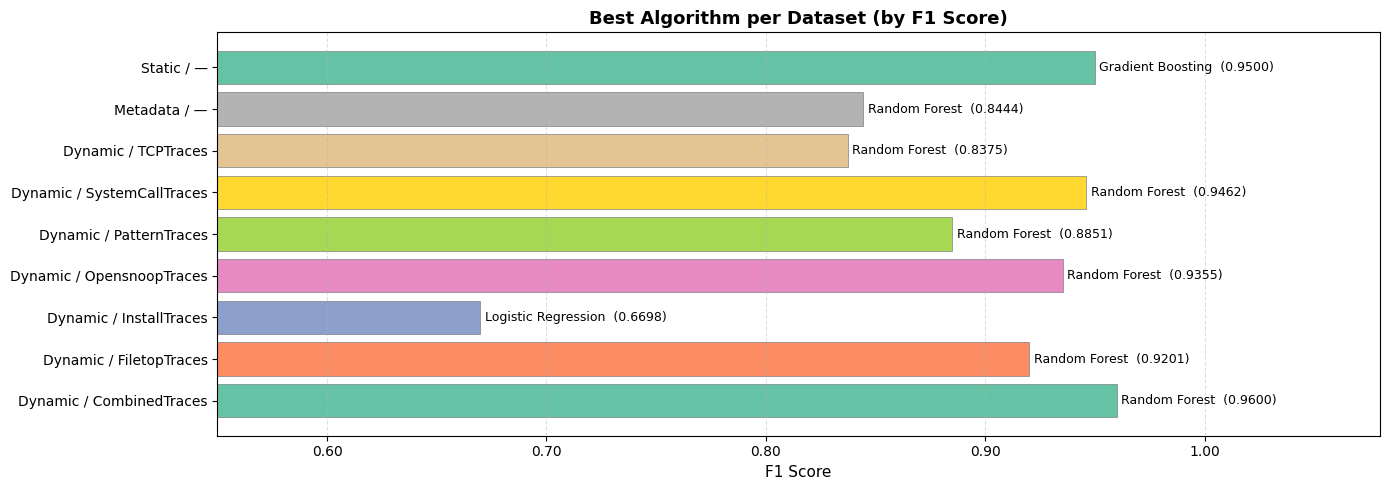

Saved → /home/runner/work/QUT-DV25/QUT-DV25/graph_best_algorithm.png


In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.Set2.colors
bars = ax.barh(best_per_ds["Dataset"], best_per_ds["F1 Score"],
               color=[colors[i % len(colors)] for i in range(len(best_per_ds))],
               edgecolor="grey", linewidth=0.5)
for bar, (_, row) in zip(bars, best_per_ds.iterrows()):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f"{row['Model']}  ({row['F1 Score']:.4f})", va="center", fontsize=9)
ax.set_xlim(0.55, 1.08)
ax.set_xlabel("F1 Score", fontsize=11)
ax.set_title("Best Algorithm per Dataset (by F1 Score)", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
out_best = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "graph_best_algorithm.png")
plt.savefig(out_best, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {os.path.abspath(out_best)}")


## 7. Overall Algorithm Comparison (Averaged across all Datasets)

Average metrics across all datasets:


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Transformer,0.9351,0.9350,0.9304,0.9327
Random Forest,0.8859,0.8989,0.8859,0.8826
Decision Tree,0.8721,0.8858,0.8721,0.8686
Gradient Boosting,0.8659,0.8812,0.8659,0.8616
Logistic Regression,0.8593,0.8734,0.8593,0.8558
SVM,0.8554,0.8711,0.8554,0.8513
KNN,0.8266,0.8445,0.8266,0.8208


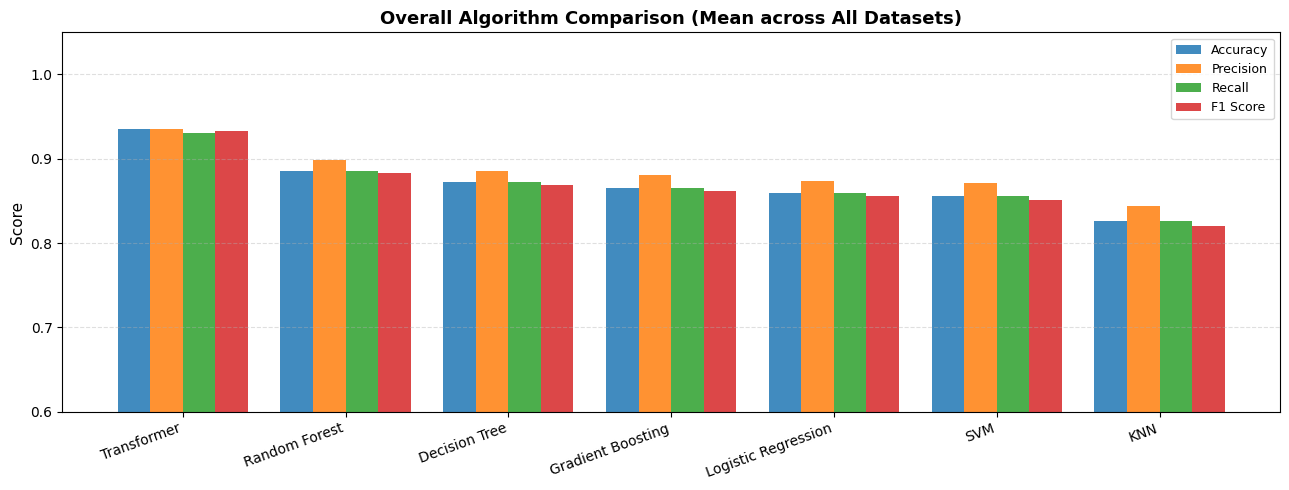

Saved → /home/runner/work/QUT-DV25/QUT-DV25/graph_overall_comparison.png


In [10]:
avg_df = (
    summary_df.dropna(subset=["F1 Score"])
    .groupby("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]]
    .mean()
    .sort_values("F1 Score", ascending=False)
    .round(4)
)
print("Average metrics across all datasets:")
display(avg_df)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(avg_df))
w = 0.2
for idx, metric in enumerate(["Accuracy", "Precision", "Recall", "F1 Score"]):
    ax.bar(x + idx*w - 0.3, avg_df[metric], w, label=metric, color=COLORS[idx], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(avg_df.index, rotation=20, ha="right", fontsize=10)
ax.set_ylim(0.6, 1.05)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Overall Algorithm Comparison (Mean across All Datasets)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
out_overall = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "graph_overall_comparison.png")
plt.savefig(out_overall, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {os.path.abspath(out_overall)}")


## 8. CNN Training History

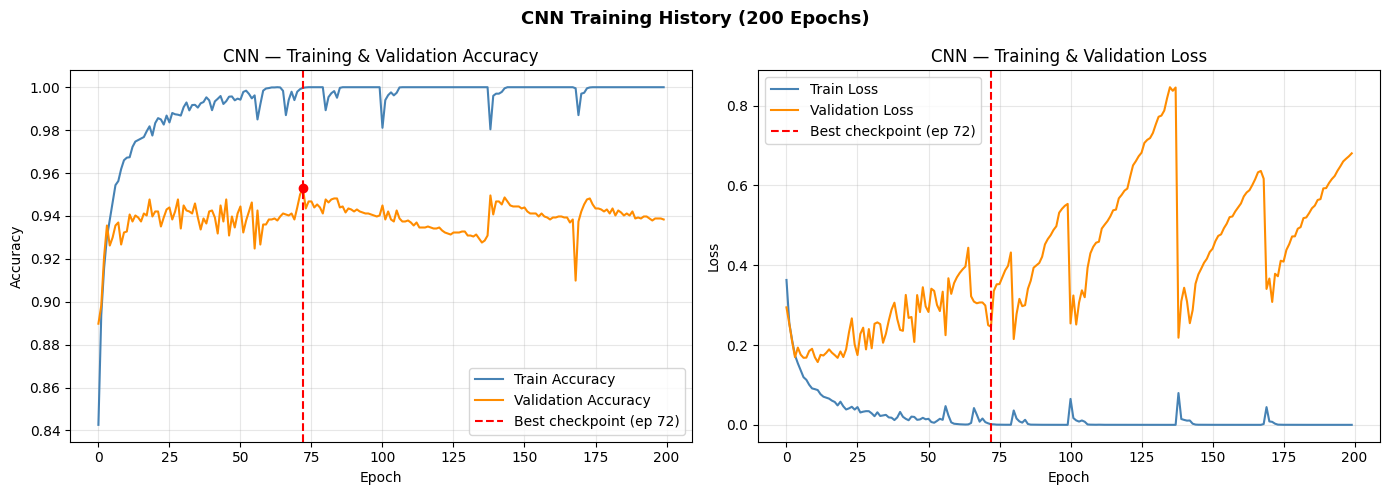

Saved → /home/runner/work/QUT-DV25/QUT-DV25/graph_cnn_history.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1, ax2 = axes

ax1.plot(cnn_hist["Epoch"], cnn_hist["Train Accuracy"],      label="Train Accuracy",      color="steelblue")
ax1.plot(cnn_hist["Epoch"], cnn_hist["Validation Accuracy"], label="Validation Accuracy",  color="darkorange")
best_ep = int(best_cnn["Epoch"])
ax1.axvline(best_ep, color="red", linestyle="--", label=f"Best checkpoint (ep {best_ep})")
ax1.scatter([best_ep], [best_cnn["Validation Accuracy"]], color="red", zorder=5)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.set_title("CNN — Training & Validation Accuracy"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(cnn_hist["Epoch"], cnn_hist["Train Loss"],      label="Train Loss",      color="steelblue")
ax2.plot(cnn_hist["Epoch"], cnn_hist["Validation Loss"], label="Validation Loss",  color="darkorange")
ax2.axvline(best_ep, color="red", linestyle="--", label=f"Best checkpoint (ep {best_ep})")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.set_title("CNN — Training & Validation Loss"); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle("CNN Training History (200 Epochs)", fontsize=13, fontweight="bold")
plt.tight_layout()
out_cnn = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "graph_cnn_history.png")
plt.savefig(out_cnn, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {os.path.abspath(out_cnn)}")
